Exited
0    7963
1    2037
Name: count, dtype: int64


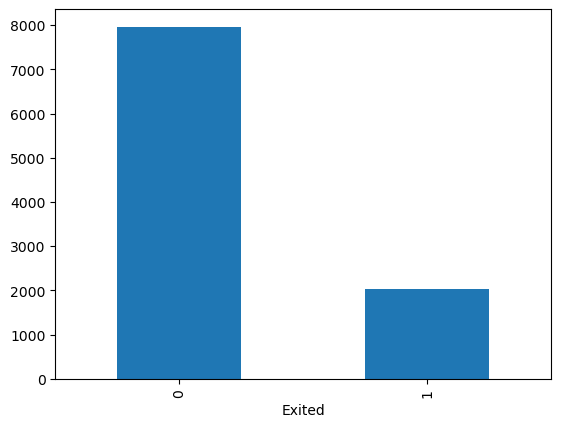

Accuracy: 0.8215
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1607
           1       0.58      0.33      0.42       393

    accuracy                           0.82      2000
   macro avg       0.72      0.63      0.66      2000
weighted avg       0.80      0.82      0.80      2000

[[1515   92]
 [ 265  128]]


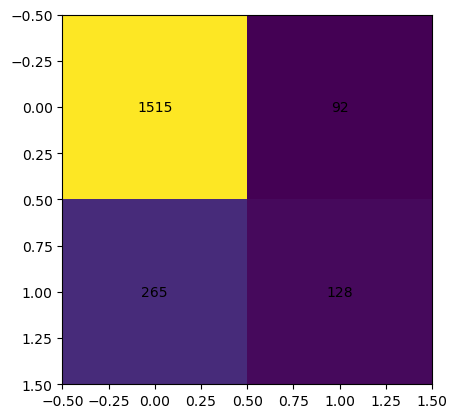

Customer will stay


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("Churn_Modelling.csv")

df = df[['CreditScore', 'Geography', 'Gender', 'Age', 'Balance', 'EstimatedSalary', 'Exited']]

le = LabelEncoder()
df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])

print(df['Exited'].value_counts())

df['Exited'].value_counts().plot(kind='bar')
plt.show()

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.imshow(cm)
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')
plt.show()

sample = [[650, 1, 1, 35, 50000, 60000]]

prediction = model.predict(sample)[0]

if prediction == 1:
    print("Customer will churn")
else:
    print("Customer will stay")